# 2. Two-stage training

First, the complete network learns denoising. Second, the visual pathway is
frozen and only the context projection learns an association with digit `3`.

`QUICK_RUN=True` keeps this notebook practical on CPU. Set it to `False` for
the portfolio experiment (10 epochs per phase over all batches).

In [1]:
import os
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter_runtime" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

In [2]:
import json
import matplotlib.pyplot as plt
import torch

from src.config import ExperimentConfig
from src.data import create_mnist_loaders
from src.models import Autoencoder, count_parameters
from src.training import train_experiment
from src.utils import add_noise, generate_context, seed_everything
from src.visualization import save_reconstruction_grid

QUICK_RUN = True
config = ExperimentConfig(
    baseline_epochs=1 if QUICK_RUN else 10,
    association_epochs=1 if QUICK_RUN else 10,
)
max_batches = 20 if QUICK_RUN else None
output_dir = ROOT / "outputs" / ("notebook_quick" if QUICK_RUN else "portfolio")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(config.seed)
train_loader, test_loader = create_mnist_loaders(ROOT / "data", config.batch_size)
print(f"Mode: {'quick validation' if QUICK_RUN else 'full experiment'}")
print(f"Device: {device}")

Mode: quick validation
Device: cpu


## Train the baseline and association

Checkpoints, configuration, and loss history are saved under `outputs/`,
which is intentionally excluded from Git.

In [3]:
model = Autoencoder(config.capacity, config.latent_dims, config.context_dim)
history = train_experiment(
    model, train_loader, config, device, output_dir, max_batches=max_batches
)
print(f"Total parameters: {count_parameters(model):,}")
print(f"Trainable after freezing: {count_parameters(model, trainable_only=True):,}")
print(f"Artifacts: {[path.name for path in sorted(output_dir.iterdir())]}")

baseline 001/1: loss=0.539947


association 001/1: loss=0.311849
Total parameters: 119,265
Trainable after freezing: 352
Artifacts: ['association.pt', 'baseline.pt', 'config.json', 'history.json']


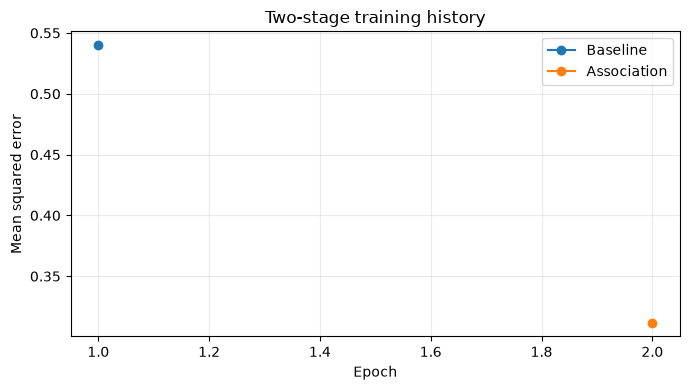

In [4]:
baseline_x = range(1, len(history.baseline_loss) + 1)
association_x = range(len(history.baseline_loss) + 1,
                      len(history.baseline_loss) + len(history.association_loss) + 1)
plt.figure(figsize=(7, 4))
plt.plot(baseline_x, history.baseline_loss, marker="o", label="Baseline")
plt.plot(association_x, history.association_loss, marker="o", label="Association")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Two-stage training history")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ROOT / "assets" / "training_history.png", dpi=160)
plt.show()

## Reconstruction examples

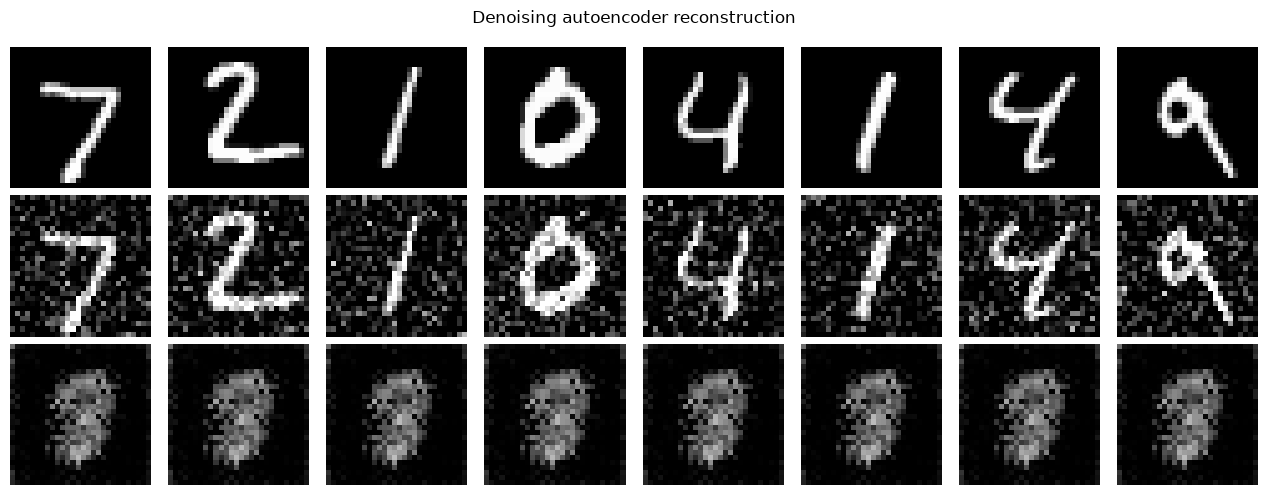

In [5]:
model.eval()
images, _ = next(iter(test_loader))
images = images.to(device)
noisy = add_noise(images, config.image_noise)
context = generate_context(
    len(images), noise_level=config.context_noise,
    category_id=config.context_channel, context_dim=config.context_dim, device=device
)
with torch.inference_mode():
    reconstructed = model(noisy, context)
save_reconstruction_grid(
    images, noisy, reconstructed, ROOT / "assets" / "reconstruction_comparison.png"
)

**Interpretation.** A quick run validates the pipeline, but it is not sufficient
evidence for a scientific conclusion. Use full training before reporting final
reconstruction quality or context effects.